In [161]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [162]:
df=pd.read_csv("insurance_dataset.csv")
df

,Age,Gender,Income,Marital_Status,Education,Occupation,Claim_Amount
0,59.0,Male,270727.0,Single,Master's,Doctor,3455
1,21.0,Female,263874.0,Single,Bachelor's,Engineer,30233
2,71.0,Female,48372.0,Single,Bachelor's,Engineer,340
3,30.0,Female,99525.0,Single,PhD,CEO,1002
4,64.0,Female,187038.0,Married,Master's,CEO,2828
...,...,...,...,...,...,...,...
12995,53.0,Female,128164.0,Single,PhD,CEO,5249
12996,41.0,Female,257518.0,Married,Bachelor's,CEO,3981
12997,25.0,Female,79060.0,Married,Bachelor's,CEO,2956
12998,42.0,Female,190633.0,Single,Master's,CEO,4029


In [163]:
df.head()

,Age,Gender,Income,Marital_Status,Education,Occupation,Claim_Amount
0,59.0,Male,270727.0,Single,Master's,Doctor,3455
1,21.0,Female,263874.0,Single,Bachelor's,Engineer,30233
2,71.0,Female,48372.0,Single,Bachelor's,Engineer,340
3,30.0,Female,99525.0,Single,PhD,CEO,1002
4,64.0,Female,187038.0,Married,Master's,CEO,2828


In [164]:
df.tail()

,Age,Gender,Income,Marital_Status,Education,Occupation,Claim_Amount
12995,53.0,Female,128164.0,Single,PhD,CEO,5249
12996,41.0,Female,257518.0,Married,Bachelor's,CEO,3981
12997,25.0,Female,79060.0,Married,Bachelor's,CEO,2956
12998,42.0,Female,190633.0,Single,Master's,CEO,4029
12999,78.0,Female,120656.0,Single,Master's,CEO,1323


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             13000 non-null  float64
 1   Gender          13000 non-null  object 
 2   Income          13000 non-null  float64
 3   Marital_Status  13000 non-null  object 
 4   Education       13000 non-null  object 
 5   Occupation      13000 non-null  object 
 6   Claim_Amount    13000 non-null  int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 711.1+ KB


In [166]:
df.describe()

,Age,Income,Claim_Amount
count,13000.000000,13000.000000,13000.000000
mean,51.530308,161718.427413,9185.646615
std,20.965770,99965.550464,15041.942150
min,18.000000,5091.000000,114.000000
25%,34.000000,75080.750000,3344.750000
50%,51.000000,154855.500000,5829.500000
75%,67.000000,235395.250000,8293.250000
max,102.421544,404427.908255,99841.000000


In [167]:
df.isnull().sum()

Age               0
Gender            0
Income            0
Marital_Status    0
Education         0
Occupation        0
Claim_Amount      0
dtype: int64

In [168]:
df.duplicated().sum()

np.int64(0)

In [169]:
df.drop_duplicates()

,Age,Gender,Income,Marital_Status,Education,Occupation,Claim_Amount
0,59.0,Male,270727.0,Single,Master's,Doctor,3455
1,21.0,Female,263874.0,Single,Bachelor's,Engineer,30233
2,71.0,Female,48372.0,Single,Bachelor's,Engineer,340
3,30.0,Female,99525.0,Single,PhD,CEO,1002
4,64.0,Female,187038.0,Married,Master's,CEO,2828
...,...,...,...,...,...,...,...
12995,53.0,Female,128164.0,Single,PhD,CEO,5249
12996,41.0,Female,257518.0,Married,Bachelor's,CEO,3981
12997,25.0,Female,79060.0,Married,Bachelor's,CEO,2956
12998,42.0,Female,190633.0,Single,Master's,CEO,4029


In [170]:
# feature engineering
bins=[0,20,40,60,100]
labels=['below 20','20 t0 39','40 to 59','above 60']
df['Age group']=pd.cut(df['Age'],labels=labels,bins=bins)
df

,Age,Gender,Income,Marital_Status,Education,Occupation,Claim_Amount,Age group
0,59.0,Male,270727.0,Single,Master's,Doctor,3455,40 to 59
1,21.0,Female,263874.0,Single,Bachelor's,Engineer,30233,20 t0 39
2,71.0,Female,48372.0,Single,Bachelor's,Engineer,340,above 60
3,30.0,Female,99525.0,Single,PhD,CEO,1002,20 t0 39
4,64.0,Female,187038.0,Married,Master's,CEO,2828,above 60
...,...,...,...,...,...,...,...,...
12995,53.0,Female,128164.0,Single,PhD,CEO,5249,40 to 59
12996,41.0,Female,257518.0,Married,Bachelor's,CEO,3981,40 to 59
12997,25.0,Female,79060.0,Married,Bachelor's,CEO,2956,20 t0 39
12998,42.0,Female,190633.0,Single,Master's,CEO,4029,40 to 59


1. Mean Charges
What is the average (mean) insurance charge for all customers?


In [171]:
df['Claim_Amount'].mean()
# ANS=Mean Charges are 9185

np.float64(9185.646615384616)

In [172]:
#2 Give gender wise average claim amount



print(df.groupby("Gender")['Claim_Amount'].mean())

#Gender
#Female    9237.692860
#Male      9132.939619

Gender
Female    9237.692860
Male      9132.939619
Name: Claim_Amount, dtype: float64


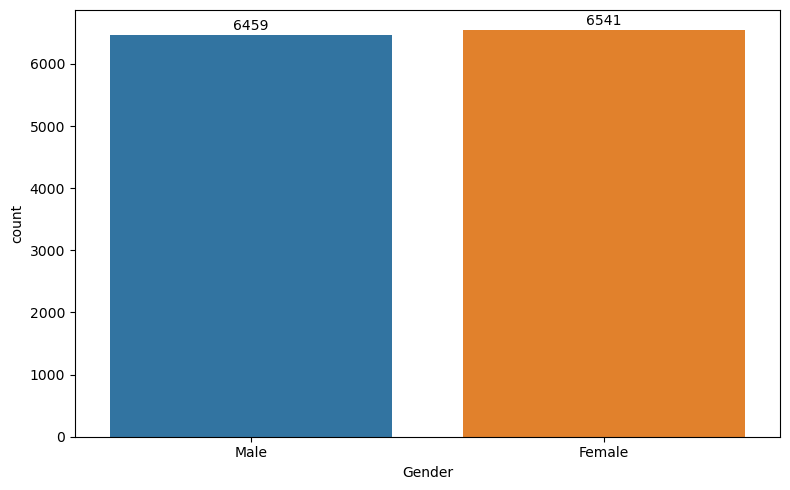

In [182]:
#3 give the Gender wise count of insurance claims with visual distribution

plt.figure(figsize=(8,5))

a1=sns.countplot(data=df,x='Gender',hue="Gender")

for i in a1.containers:
    a1.bar_label(i,padding=2)


plt.tight_layout()
plt.show()


Marital_Status
Married    6487
Single     6513
Name: Claim_Amount, dtype: int64


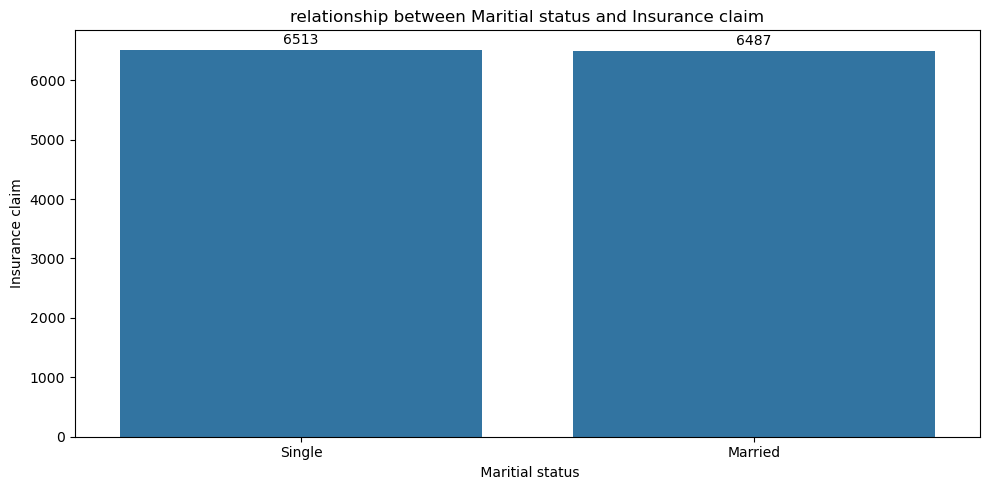

In [186]:
4# Give relationship between Maritial status and Insurance claim

print(df.groupby("Marital_Status")['Claim_Amount'].count())

plt.figure(figsize=(10,5))

v2=sns.barplot(data=df,x='Marital_Status', y='Claim_Amount', estimator='count',errorbar=None)

for i in v2.containers:
    v2.bar_label(i,padding=2)

plt.title("relationship between Maritial status and Insurance claim")
plt.xlabel(" Maritial status")
plt.ylabel("Insurance claim")
plt.tight_layout()
plt.show()


Education
Master's      4383
PhD           4321
Bachelor's    4296
Name: count, dtype: int64


([<matplotlib.patches.Wedge at 0x1cf69f28e10>,
 [Text(0.5385267442380757, 0.9591605422140438, "Master's"),
  Text(-1.0997568804227214, -0.023125828912375357, 'PhD'),
  Text(0.5585722444951794, -0.9476270614960389, "Bachelor's")],
 [Text(0.2937418604934958, 0.5231784775712965, '33.7%'),
  Text(-0.5998673893214843, -0.012614088497659284, '33.2%'),
  Text(0.3046757697246433, -0.5168874880887485, '33.0%')])

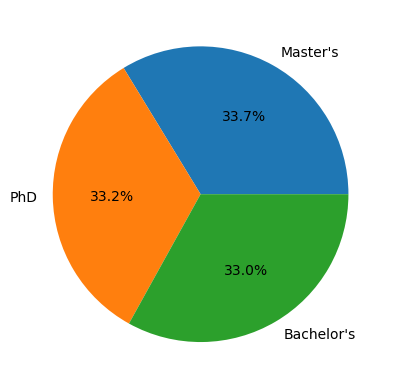

In [187]:
5# Give Claim  distrubution based on educational qualification 
v3=df['Education'].value_counts()
print(v3)
plt.pie(v3.values,labels=v3.index, autopct="%1.1f%%")

Occupation
CEO         66805527
Doctor      13753359
Engineer    13727144
Waiter      13361092
Teacher     11766284
Name: Claim_Amount, dtype: int64


([<matplotlib.patches.Wedge at 0x1cf6a011810>,
 [Text(-0.2042435712243034, 1.0808721310189948, 'CEO'),
  Text(-0.8157550889282424, -0.73793199882352, 'Doctor'),
  Text(-0.12346013789664398, -1.0930496760671684, 'Engineer'),
  Text(0.5826466738627408, -0.9330181420726422, 'Teacher'),
  Text(1.0327393011410777, -0.37874732458281285, 'Waiter')],
 [Text(-0.11140558430416547, 0.5895666169194517, '55.9%'),
  Text(-0.4449573212335867, -0.4025083629946472, '11.5%'),
  Text(-0.06734189339816943, -0.5962089142184555, '11.5%'),
  Text(0.31780727665240405, -0.5089189865850775, '9.9%'),
  Text(0.5633123460769514, -0.20658944977244334, '11.2%')])

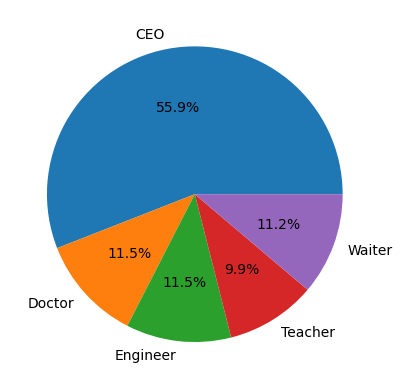

In [190]:
6# Give Claim  distrubution based on occupation and TOP 3 occupations 
occ=df.groupby('Occupation')['Claim_Amount'].sum()

print(occ.sort_values(ascending=False))
plt.pie(occ.values,labels=occ.index, autopct="%1.1f%%")

# top 3 occupations
#CEO         66805527
#Doctor      13753359
#Engineer    13727144

C:\Users\Admin\AppData\Local\Temp\ipykernel_4596\3342010533.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  var1=sns.barplot(data=df,x='Age group', y='Claim_Amount' , ci=None)


<Figure size 1000x500 with 0 Axes>

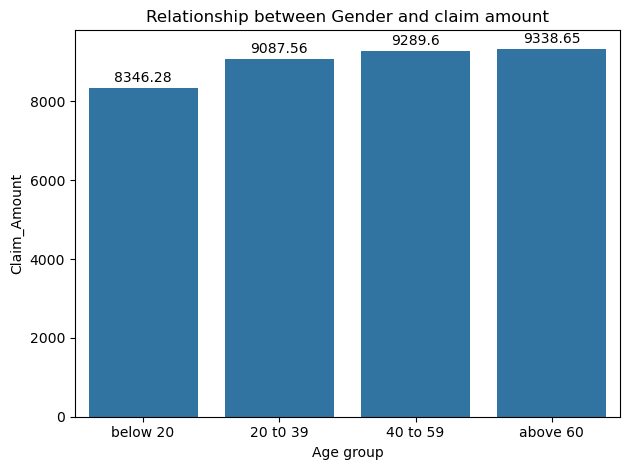

In [194]:
7# Give distrubtion based on age groups and give Highest and lowerst age group category
plt.figure(figsize=(10,5))
fig,ax= plt.subplots()

var1=sns.barplot(data=df,x='Age group', y='Claim_Amount' , ci=None)

for i in ax.containers:
    ax.bar_label(i,  padding=2)
    
plt.title("Relationship between Gender and claim amount")
plt.tight_layout()


In [200]:
8# find the number of applicants who has Claim_Amount more than 50,000

df[df['Claim_Amount']>50000].shape[0]


544

C:\Users\Admin\AppData\Local\Temp\ipykernel_4596\3698639173.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot= df.pivot_table(


<Axes: xlabel='Age group', ylabel='Education'>

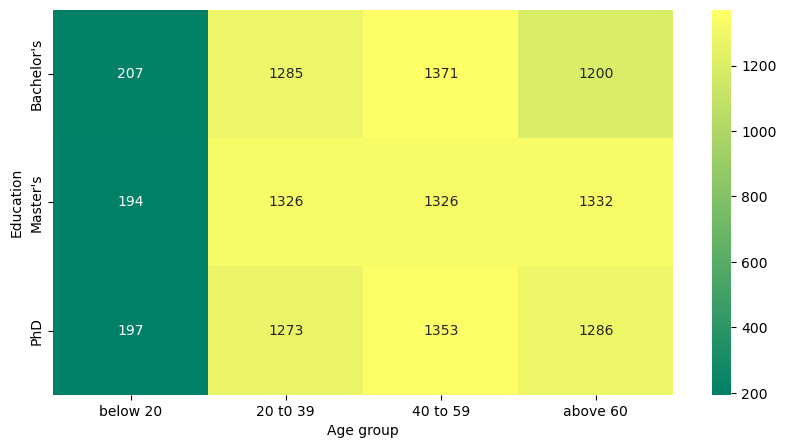

In [179]:
# 9 give heatmap for relationship between age group and occupation with respect to claim amount

plt.figure(figsize=(10,5))

pivot= df.pivot_table(
    index="Education",
    values="Claim_Amount",
    columns='Age group',
    aggfunc='count'
)
'Education'>
sns.heatmap(pivot,annot=True,cmap='summer',fmt='.0f')

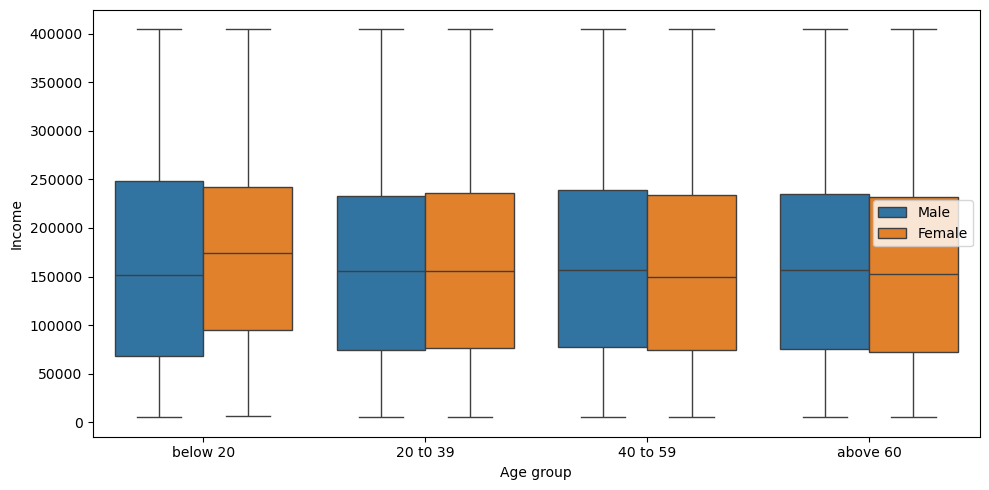

In [180]:
# 10 give Give the distribution between-->age group and  claim amount wih respect to gender 

plt.figure(figsize=(10,5))
z=sns.boxplot(data=df,x="Age group",hue="Gender",y="Income")

plt.legend(loc='best')
plt.tight_layout()
plt.show()




#11 give Insights and summary to the Managament ,so that managament can take data driven decisions
###
Minimum insurance clain amount is :114,
Maximum insurance clain amount is :	99841
Average claim amount is: 9185

There is no major difference between male and female for insurance claim
There is no major difference between single  and married people for insurance claim

Among Education wise distribution Master have Highest number of insurance claim (4383)

Among Occupation  wise distribution CEO's  have Highest number of insurance claim (4383)
TOP 3 categories are 
CEO         66805527
Doctor      13753359
Engineer    13727144

Highest number of insurance claims coming form Above 60 age group and lowest from below 20 age group ,
Howerver there is no major difference
###